# <center> Chapter 1 | RAG Fundamentals </center >

 **Where this sits:** This is the foundation. If this chapter is crystal clear, then
 chunking, embeddings, vector databases, reranking, GraphRAG and Agentic RAG all become
 much easier - they are each just *one box* in the pipeline you are about to build.

**What you will be able to do by the end:**

1. Explain what RAG is, and what it is *not*, at interview depth
2. Draw the two pipelines (offline indexing + online query) from memory
3. Implement a complete naive RAG system in pure Python — no LangChain, no LlamaIndex
4. Implement cosine similarity by hand and know why we use it
5. Diagnose a wrong answer as a **retrieval failure** vs a **generation failure**
6. Avoid the seven classic interview traps

---

## Table of contents

| § | Topic |
|---|-------|
| 1 | What exactly is RAG? |
| 2 | Why we need RAG — the frozen-knowledge problem |
| 3 | Parametric vs non-parametric knowledge |
| 4 | The exam analogy |
| 5 | The two pipelines |
| 6 | The mathematics of retrieval |
| 7 | **Build it:** naive RAG from scratch |
| 8 | The hallucination problem |
| 9 | RAG vs fine-tuning vs long context |
| 10 | Failure modes and the debugging ladder |
| 11 | Interview traps & questions |


## Setup

Run this once. It checks your environment and imports the shared helpers.

If you have not set up `.env` yet: copy `.env.example` to `.env` and paste your OpenAI key.

In [16]:
# `sys` lets us modify Python's module search path.
import sys

# Add the project root (one level up from this notebook) so `utils` is importable.
sys.path.append("..")

# `os` reads environment variables - used directly below to show the raw
# Azure OpenAI call, not just through the wrapper.
import os

# numpy gives us fast vector maths - the backbone of every similarity calculation.
import numpy as np

# Pull in the shared plumbing: embeddings, chat, and the credential loader.
from utils.rag_helpers import embed_texts, embed_text, chat, load_env

# Check whether usable API credentials were found in .env.
HAS_KEY = load_env()

# Tell the user what mode the notebook will run in.
print("API credentials found - live embeddings & generation enabled." if HAS_KEY
      else "No API credentials. Sections using the API will be skipped; the maths still runs.")

API credentials found - live embeddings & generation enabled.


## What is actually happening under the hood

1. `embed_texts` and `chat` (imported above from `utils.rag_helpers`) are convenience
wrappers. Convenient for later notebooks, but they **hide the actual API call** - and
seeing that call once is the point of this section.

2. Below is the **exact same request**, written directly against the Azure OpenAI SDK, no
wrapper. 

3. Run it once here so you know precisely what "embedding" and "chat completion"
mean at the wire level. Every later cell in this notebook goes back to using the short
`embed_texts` / `chat` wrappers - this cell exists purely so nothing is a black box.

In [57]:
# Only run this demonstration if a key is configured.
if HAS_KEY:

    # Import the Azure client directly - no wrapper.
    from openai import AzureOpenAI

    # Build the client with the three pieces Azure needs beyond a plain API key:
    # the key itself, the resource endpoint, and the API version.
    raw_client = AzureOpenAI(
        api_key=os.environ["AZURE_OPENAI_API_KEY"],
        azure_endpoint=os.environ["AZURE_OPENAI_ENDPOINT"],
        api_version=os.getenv("AZURE_OPENAI_API_VERSION", "2024-10-21"),
    )

    # The `model` argument is actually a DEPLOYMENT NAME on Azure - the name you
    # gave the model when you deployed it in Azure AI Foundry, not the raw
    # model name like "text-embedding-3-small".
    embedding_deployment = os.getenv("AZURE_OPENAI_EMBEDDING_DEPLOYMENT", "text-embedding-3-small")

    # This is the ENTIRE embedding call. One HTTP request, one piece of text in.
    raw_response = raw_client.embeddings.create(
        model=embedding_deployment,
        input="Employees receive 24 annual leaves every year.",
    )

    # The response is a list of "embedding objects" - one per input string.
    # We sent one string, so we get exactly one object back.
    print("Number of embeddings returned:", len(raw_response.data))
    print()

    # Each object holds the raw vector under `.embedding` - a plain list of floats.
    raw_vector = raw_response.data[0].embedding

    # This length is fixed by the model, not by our input text.
    print("Vector length (embedding dimension):", len(raw_vector[:5]))
    print()
    
    # The first few numbers - this is genuinely all an embedding is: floats.
    print("First 8 numbers:", raw_vector)
    print()
    
    # The API also reports token usage - this is what you are billed for.
    print("Tokens used for this call:", raw_response.usage.total_tokens)
    print()

Number of embeddings returned: 1

Vector length (embedding dimension): 5

First 8 numbers: [-0.01459503173828125, 0.045166015625, 0.08111572265625, 0.0546875, -0.01001739501953125, 0.0016384124755859375, 0.0244903564453125, 0.031402587890625, 0.00846099853515625, -0.01445770263671875, 0.01324462890625, -0.0261383056640625, 0.03680419921875, 0.0089569091796875, 0.0521240234375, -0.01105499267578125, 0.01132965087890625, -0.01922607421875, -0.026092529296875, 0.0325927734375, 0.0362548828125, 0.049774169921875, 0.0011138916015625, -0.0123443603515625, 0.011932373046875, 0.032073974609375, -0.0721435546875, -0.00811004638671875, -0.0015878677368164062, -0.02276611328125, 0.030242919921875, -0.00982666015625, 0.0067596435546875, -0.00757598876953125, 0.06964111328125, 0.04986572265625, 0.05908203125, 0.01641845703125, 0.0177459716796875, -0.0222930908203125, -0.006542205810546875, 0.00640869140625, 0.03985595703125, -0.030975341796875, 0.0035610198974609375, 0.0231170654296875, -0.02124023

### See the vector, not just its shape

`raw_vector` is 1536 numbers. A shape and eight sample values don't build intuition.
Plot it instead — once you *see* an embedding, "1536-dimensional vector" stops being
abstract.

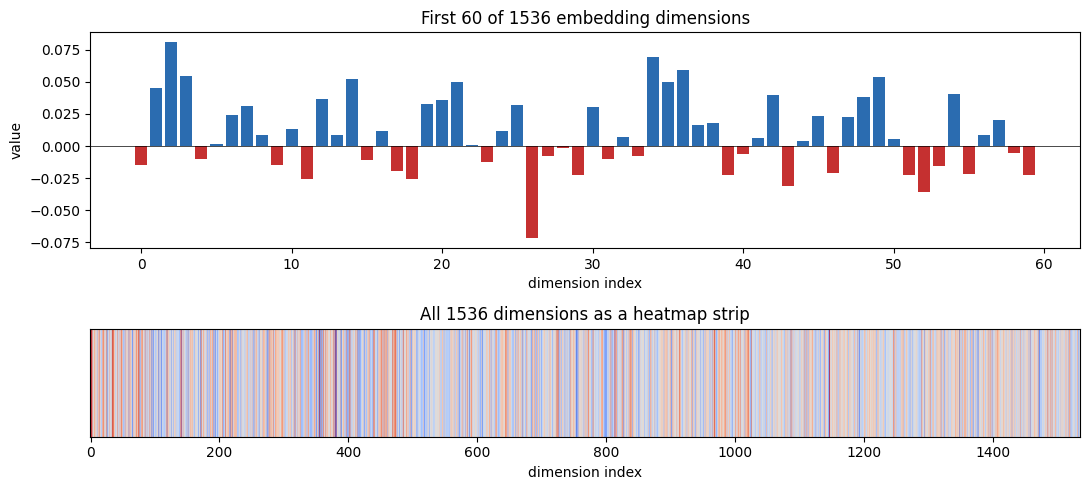

In [58]:
# Only run this visualization if a key is configured.
if HAS_KEY:

    # matplotlib is the standard plotting library - import it once, use it everywhere.
    import matplotlib.pyplot as plt

    # Build two stacked plots: a zoomed-in bar chart, and the full vector as a heatmap.
    figure, (bar_axis, heatmap_axis) = plt.subplots(
        2, 1, figsize=(11, 5), gridspec_kw={"height_ratios": [2, 1]}
    )

    # Only plot the first 60 dimensions as bars - all 1536 would be unreadable.
    n_dims_to_show = 60

    # Colour positive values blue, negative values red - makes sign jump out visually.
    bar_colors = ["#2b6cb0" if value >= 0 else "#c53030" for value in raw_vector[:n_dims_to_show]]

    # Draw the bar chart of the first 60 numbers.
    bar_axis.bar(range(n_dims_to_show), raw_vector[:n_dims_to_show], color=bar_colors)
    bar_axis.set_title(f"First {n_dims_to_show} of {len(raw_vector)} embedding dimensions")
    bar_axis.set_xlabel("dimension index")
    bar_axis.set_ylabel("value")

    # A horizontal line at zero makes positive/negative easy to read.
    bar_axis.axhline(0, color="black", linewidth=0.5)

    # Now show ALL 1536 dimensions at once, as a single row of coloured pixels.
    # reshape(1, -1) turns the flat vector into a 1-row "image" imshow can draw.
    heatmap_axis.imshow(
        [raw_vector], aspect="auto", cmap="coolwarm", vmin=-0.08, vmax=0.08
    )
    
    heatmap_axis.set_title(f"All {len(raw_vector)} dimensions as a heatmap strip")
    heatmap_axis.set_yticks([])
    heatmap_axis.set_xlabel("dimension index")

    plt.tight_layout()
    plt.show()

Read the heatmap left to right: **that entire strip of red and blue is the complete
meaning representation** of *"Employees receive 24 annual leaves every year."* — no
dimension is individually labelled "leave count" or "policy type". Meaning is spread
across all 1536 numbers together, which is exactly why we compare whole vectors with
cosine similarity rather than reading any single dimension.

Read that output literally: an embedding is **one flat list of floating-point numbers**,
one per input string, always the same length regardless of how long the input text was.
"Employees receive 24 annual leaves every year." became a fixed-size list of numbers —
nothing more mysterious than that.

Now the same exercise for generation.

In [19]:
# Only run this demonstration if a key is configured.
if HAS_KEY:

    # Same idea: model is a deployment name, not a raw model name.
    chat_deployment = os.getenv("AZURE_OPENAI_CHAT_DEPLOYMENT", "gpt-4o-mini")

    # This is the ENTIRE chat completion call - a list of role/content messages in.
    raw_chat_response = raw_client.chat.completions.create(
        model=chat_deployment,
        temperature=0.0,
        messages=[
            {"role": "system", "content": "You are a concise assistant."},
            {"role": "user", "content": "In one sentence, what is an embedding?"},
        ],
    )

    # The reply text lives several levels deep in the response object.
    print("Reply:", raw_chat_response.choices[0].message.content)

    # Every call reports how many tokens went in and came out - this is what costs money.
    print("\nPrompt tokens:", raw_chat_response.usage.prompt_tokens)
    print("Completion tokens:", raw_chat_response.usage.completion_tokens)
    print("Total tokens:", raw_chat_response.usage.total_tokens)

Reply: An embedding is a mathematical representation that maps objects, such as words or images, into continuous vector spaces while preserving their meaningful relationships.

Prompt tokens: 26
Completion tokens: 26
Total tokens: 52


Two calls, two shapes of response:

| | Input | Output | Billed on |
|---|---|---|---|
| **Embedding** | one string | one fixed-length list of floats | input tokens only |
| **Chat** | a list of role/content messages | one generated string | input **and** output tokens |

That is the entire API surface this whole course builds on. Everything from here —
`embed_texts`, `create_document_embeddings`, cosine similarity, retrieval, `naive_rag` —
is just **orchestration around these two calls**. From this point on the notebook uses
the short `embed_texts` / `chat` wrappers so the RAG logic stays readable, but you now
know exactly what they do underneath.


# 1. What exactly is RAG?

**RAG = Retrieval-Augmented Generation.**

The one-sentence definition:

> Instead of asking an LLM to answer only from what it learned during training, we first
> **retrieve** relevant external information and give that information to the LLM as context.

Read the name backwards and it explains itself:

```
Retrieval  +  Augmented  +  Generation
    │            │              │
    │            │              └── the LLM generates the answer
    │            │
    │            └── the prompt is augmented with external knowledge
    │
    └── we retrieve relevant knowledge first
```

### The architecture

```
                    User Question
                          │
                          ▼
                  ┌───────────────┐
                  │   Retriever   │
                  └───────┬───────┘
                          │
              Search external knowledge
                          │
                          ▼
          ┌───────────────────────────┐
          │    Relevant Documents     │
          │      Chunk 1              │
          │      Chunk 2              │
          │      Chunk 3              │
          └─────────────┬─────────────┘
                        │
                        ▼
              Question + Documents
                        │
                        ▼
                ┌───────────────┐
                │      LLM      │
                └───────┬───────┘
                        │
                        ▼
                     Answer
```

So RAG has exactly **two major components**:

```
RAG
│
├── Retrieval   →  find useful information
│
└── Generation  →  generate an answer using that information
```

Keep this split in your head. Almost every RAG bug you will ever debug belongs to one
side or the other.

---
# 2. Why do we even need RAG?

## 2.1 A concrete failure

Imagine your company has a private document:

```
Siemens Leave Policy 2026

Employees are allowed:
 - 24 paid leaves
 - 12 sick leaves
 - 3  optional holidays
```

You ask a plain LLM:

> *How many paid leaves does our company provide in 2026?*

The model never saw that internal document during training. So it either:

| Failure | Example output | Problem |
|---------|----------------|---------|
| **Hedging** | *"It depends on company policy. Typical companies provide 20–30 days…"* | Useless |
| **Hallucinating** | *"Employees receive 30 paid leaves."* | Confidently wrong — worse |

## 2.2 What RAG changes

```
Question
   │
   ▼
"How many paid leaves does our company provide?"
   │
   ▼
Search company documents
   │
   ▼
Retrieve: "Employees receive 24 paid leaves."
   │
   ▼
Give this to LLM:

    Context:
    Employees receive 24 paid leaves.

    Question:
    How many paid leaves do employees receive?
   │
   ▼
LLM
   │
   ▼
"Employees receive 24 paid leaves."
```

The critical insight:

> The LLM does **not** need to *memorize* the policy.
> It only needs to **reason over** the retrieved policy.

## 2.3 The root cause: LLM knowledge is frozen

An LLM trained until some time *T* has parameters $\theta$. Training bakes patterns and
knowledge into those parameters. Then they freeze:

```
Internet / Books / Code / Data
            │
            ▼
       LLM Training
            │
            ▼
     Neural Network Weights
            │
            ▼
      Frozen Knowledge
```

And the world keeps moving:

```
January    Model training finishes
              ↓
February   Company changes refund policy
              ↓
March      User asks model about refund policy
```

The model cannot know about February's change. Its weights were frozen in January.

**RAG's core move is a separation of concerns:**

```
Reasoning capability      (stays in the model's weights)
        from
Knowledge storage         (moves to an external, updatable store)
```

## 2.4 The economics of that separation

| | Fine-tuning | RAG |
|---|---|---|
| Policy changes from 14 → 30 days | Collect data → prepare dataset → train → evaluate → deploy | Update document → re-index → done |
| Time | Hours to days | Seconds to minutes |
| Cost | High | Low |

This is *the* reason RAG took over enterprise AI.


# 3. Parametric vs non-parametric knowledge

This distinction comes up in interviews constantly. Learn the vocabulary.

## 3.1 Parametric knowledge

Knowledge encoded **inside the model's parameters**.

```
GPT model
   │
   ├── billions of parameters
   │
   ├── language patterns
   ├── world knowledge
   ├── reasoning patterns
   └── learned relationships
```

Mathematically the model computes:

$$P(y \mid x; \theta)$$

where $x$ = user input, $y$ = generated response, $\theta$ = learned parameters.

*Example:* "What is the capital of France?" → the mapping France → Paris lives inside
$\theta$. No database required.

## 3.2 Non-parametric knowledge

RAG introduces an **external knowledge store**:

```
PDFs · Word documents · Web pages · Database records
Vector database · Knowledge graph · Search engine · APIs
```

This information is **not** inside the LLM weights. Hence: **non-parametric memory**.

```
             LLM
      Parametric Memory
             +
             │
             │
      External Knowledge
    Non-parametric Memory
             │
             ▼
        Final Answer
```

## 3.3 Side-by-side

| Property | Parametric | Non-parametric |
|---|---|---|
| Lives in | Model weights $\theta$ | External store |
| Update cost | Retrain / fine-tune | Re-index one document |
| Inspectable | No | Yes |
| Citable | No | Yes |
| Access-controllable | No | Yes |
| Capacity | Fixed by model size | Effectively unlimited |

That last column is why enterprises adopted RAG: **updatable, inspectable, citable,
permission-aware knowledge.**


# 4. The exam analogy

The clearest intuition for RAG.

### Student A — plain LLM (closed-book exam)

```
Question
   │
   ▼
Memory
   │
   ▼
Answer
```

Remembers correctly → good. Doesn't remember → guesses.

### Student B — RAG system (open-book exam)

```
Question
   │
   ▼
Search textbook
   │
   ▼
Find relevant page
   │
   ▼
Read page
   │
   ▼
Reason
   │
   ▼
Answer
```

Student B doesn't need to memorize everything.

### But there's a catch

**What if Student B searches the wrong page?**

Then even a brilliant student answers incorrectly. This gives us one of the biggest
principles in the entire field:

> ### Generation quality is highly dependent on retrieval quality.

You will hear this phrased as:

```
Garbage retrieval
      ↓
Garbage context
      ↓
Garbage answer
```

A useful (informal, not a literal law) mental model:

$$\text{RAG Quality} \approx \text{Retrieval Quality} \times \text{Generation Quality}$$

If your retriever scores 0.50 and your generator scores 0.95, your system is *still* bad.
**An excellent LLM cannot answer from information it never receives.** This is why
production RAG teams spend most of their effort on chunking, retrieval, hybrid search,
reranking and evaluation — not on prompt wording.


# 5. The two pipelines

A production RAG system is really **two separate systems** with very different
engineering requirements.

```
                      RAG SYSTEM

        ┌─────────────────────┐
        │  Offline Pipeline   │
        │ Knowledge Ingestion │
        └─────────────────────┘
                    +
        ┌─────────────────────┐
        │  Online Pipeline    │
        │ Question Answering  │
        └─────────────────────┘
```

## 5.1 Offline indexing pipeline

Happens **before** any user asks anything.

```
Documents
    │
    ▼
 Parsing
    │
    ▼
 Cleaning
    │
    ▼
 Chunking
    │
    ▼
Embeddings
    │
    ▼
Vector Index
    │
    ▼
Vector Database
```

Concretely:

```
Employee_Handbook.pdf
        │
        ▼
   Extract text
        │
        ▼
  Split into chunks  →  Chunk 1, Chunk 2, Chunk 3, Chunk 4
        │
        ▼
Convert each chunk into a vector
        │
        ▼
    Store vectors
```

## 5.2 Online query pipeline

Happens **when a user asks a question**.

```
User Query
    │
    ▼
Query Embedding
    │
    ▼
Vector Search
    │
    ▼
Top-K chunks
    │
    ▼
Optional Reranking
    │
    ▼
Context Construction
    │
    ▼
  Prompt
    │
    ▼
   LLM
    │
    ▼
 Answer
```

## 5.3 Why the split matters (system design)

```
        INDEXING PIPELINE          QUERY PIPELINE
             Offline                   Online

        Documents                     User
            │                           │
          Parse                       Query
            │                           │
          Chunk                       Embed
            │                           │
          Embed                       Search
            │                           │
          Index                      Retrieve
            │                           │
          Store                      Generate
```

| | Indexing | Query |
|---|---|---|
| Latency budget | Minutes to hours | Milliseconds to seconds |
| Runs | Batch / on document change | Every single request |
| Scaling concern | Throughput | Concurrency + tail latency |
| Failure impact | Stale index | User-visible error |

Different requirements → different architecture. Interviewers probe this.

## 5.4 What "advanced RAG" eventually looks like

Chapter 1 builds the simplest version. For orientation, here is where we're heading by
Chapter 22:

```
                     USER
                       │
                       ▼
             Query Understanding
                       │
                       ▼
             Query Transformation
                       │
        ┌──────────────┴──────────────┐
        ▼                             ▼
  Dense Retrieval               BM25 Retrieval
        │                             │
        └──────────────┬──────────────┘
                       ▼
                  Fusion / RRF
                       │
                       ▼
                    Top 50
                       │
                       ▼
                   Reranker
                       │
                       ▼
                     Top 5
                       │
                       ▼
              Context Compression
                       │
                       ▼
                 Prompt Builder
                       │
                       ▼
                      LLM
                       │
                       ▼
               Grounded Answer
                       │
                       ▼
                  Citations
```


# 6. The mathematics of retrieval

## 6.1 What a retriever answers

> *Which pieces of information are most relevant to the user's question?*

Suppose our knowledge base contains:

```
D1: Employees receive 24 annual leaves.
D2: The company's headquarters are located in Munich.
D3: Employees receive health insurance.
D4: Employees can carry forward 10 annual leaves.
```

User asks: *"How many annual leaves do employees receive?"*

A good retriever ranks: **D1** (very relevant) → D4 → D3 → D2.

## 6.2 Formal setup

Let there be documents:

$$D = \{d_1, d_2, \dots, d_n\}$$

An **embedding function** maps text into a $m$-dimensional vector space:

$$E(x): \text{text} \rightarrow \mathbb{R}^m$$

Embed the query and every document:

$$q = E(Q) \qquad v_i = E(d_i)$$

Score each document by cosine similarity:

$$s_i = \cos(q, v_i)$$

Take the top $K$:

$$\text{TopK}(Q) = \arg\text{topk}_{d_i \in D}\; s_i$$

Example scores:

| Document | Similarity |
|---|---|
| D1 | 0.92 |
| D2 | 0.83 |
| D3 | 0.76 |
| D4 | 0.32 |
| D5 | 0.19 |

With $K = 3$ we retrieve D1, D2, D3.

## 6.3 Why cosine similarity?

$$\cos(q, d) = \frac{q \cdot d}{\lVert q \rVert \, \lVert d \rVert}$$

The numerator $q \cdot d$ is the **dot product** — it measures how much the two vectors
point the same way. The denominator divides out both **magnitudes**, so only *direction*
remains.

Why does direction matter more than magnitude? Because embedding magnitude tends to track
text *length*, not text *meaning*. A one-sentence answer and a three-paragraph answer about
the same topic should score similarly. Cosine similarity gives us that for free.

Range: $-1$ (opposite) … $0$ (unrelated) … $1$ (identical direction).

```
Embedding Space

                "employee leave"
                      ● D1
                     /
                    /
                 ● Query


                                   ● D2
                              "company address"


        ● D3
   "health insurance"
```

```
Similarity(Query, D1) = 0.96
Similarity(Query, D3) = 0.54
Similarity(Query, D2) = 0.21
```

## 6.4 The generation side, formally

After retrieval we have query $Q$ and retrieved documents $D_k = \{d_1, \dots, d_k\}$.

The LLM now computes approximately:

$$P(Y \mid Q, D_k)$$

instead of plain generation:

$$P(Y \mid Q)$$

**The external context changes the probability distribution over generated tokens.** That
is the whole mechanism. Nothing is "trained".

## 6.5 The probabilistic view — and why it's the key to debugging

A simplified formulation of RAG:

$$P(y \mid x) = \sum_z P(z \mid x)\, P(y \mid x, z)$$

where $x$ = question, $z$ = retrieved document, $y$ = answer.

- $P(z \mid x)$ = probability that document $z$ is the right evidence
- $P(y \mid x, z)$ = probability of the answer given query + document

This equation tells you **RAG contains exactly two uncertainties**:

```
Question
   │
   ▼
Which document?        ← P(z | x)
   │
   ▼
Given document,
what answer?           ← P(y | x, z)
```

Therefore errors happen in exactly two places:

| Error type | What happened |
|---|---|
| **Retrieval error** (wrong $z$) | Correct information exists, retriever didn't find it |
| **Generation error** (correct $z$, wrong $y$) | Correct chunk retrieved, LLM misread or hallucinated |

**Memorize this decision tree.** It is the first thing a strong Applied AI engineer reaches
for:

```
                Wrong Answer
                     │
                     ▼
            Was correct evidence
                retrieved?
               /          \\
             NO            YES
              │             │
              ▼             ▼
     Retrieval issue   Generation issue
```

###  7. Build it — naive RAG from scratch

We will deliberately avoid LangChain and LlamaIndex so you see exactly what happens
underneath them.

```
Documents
    │
    ▼
Embedding Model
    │
    ▼
  Vectors
    │
    ▼
   Query
    │
    ▼
Query Vector
    │
    ▼
Cosine Similarity
    │
    ▼
  Top-K
```

Each step is its own function. No giant nested method — you should be able to read, run
and modify any single step in isolation.

### Step 1 — the documents

Imagine each string is a chunk extracted from a PDF.

In [37]:
# Create a list containing our knowledge-base documents.
documents = [
    "Employees receive 24 annual leaves every year.",
    "Employees receive medical insurance benefits.",
    "Employees can carry forward up to 10 unused leaves.",
    "The company headquarters are located in Munich.",
]

# Print each document with its index so we can refer to them later.
for index, document in enumerate(documents):

    # Print the index and there respective documents on that index
    print(f"D{index}: {document}")

D0: Employees receive 24 annual leaves every year.
D1: Employees receive medical insurance benefits.
D2: Employees can carry forward up to 10 unused leaves.
D3: The company headquarters are located in Munich.


### Step 2 — create document embeddings

This is the **offline indexing pipeline**, compressed into one function call. In a real
system this runs once, in batch, and the vectors are persisted to a vector database.

Conceptually:

```
D1 ──► [0.32, 0.14, 0.71, ...]
D2 ──► [0.54, 0.18, 0.19, ...]
D3 ──► [0.27, 0.51, 0.63, ...]
D4 ──► [0.91, 0.05, 0.13, ...]
```

In [38]:
# Define a function that converts a list of documents into embedding vectors.
def create_document_embeddings(documents):

    # Send all documents in ONE API call - batching is far cheaper than one call each.
    document_embeddings = embed_texts(documents)

    # Return the resulting matrix of shape (n_documents, embedding_dimension).
    return document_embeddings


# Only call the API if a key is configured.
if HAS_KEY:

    # Generate embeddings for our knowledge-base documents.
    document_embeddings = create_document_embeddings(documents)

    # Show the shape: one row per document, one column per embedding dimension.
    print("Shape:", document_embeddings.shape)

    # Peek at the first 8 numbers of the first document's vector.
    print("First 8 values of D0:", document_embeddings[0][:8])

Shape: (4, 1536)
First 8 values of D0: [-0.01462555  0.0451355   0.08111572  0.05462646 -0.01003265  0.00165367
  0.02445984  0.03140259]


### Visualize all four document embeddings at once

Two views of the same data:

1. **Heatmap** - each document as one row. Similar documents should show similar
   colour patterns.
2. **2D projection (PCA)** - 1536 dimensions compressed down to the 2 directions that
   capture the most variation, so we can literally plot documents as dots and see which
   ones sit close together.

PCA loses information (we go from 1536 numbers to 2), but it is the standard way to make
high-dimensional embeddings visually inspectable.

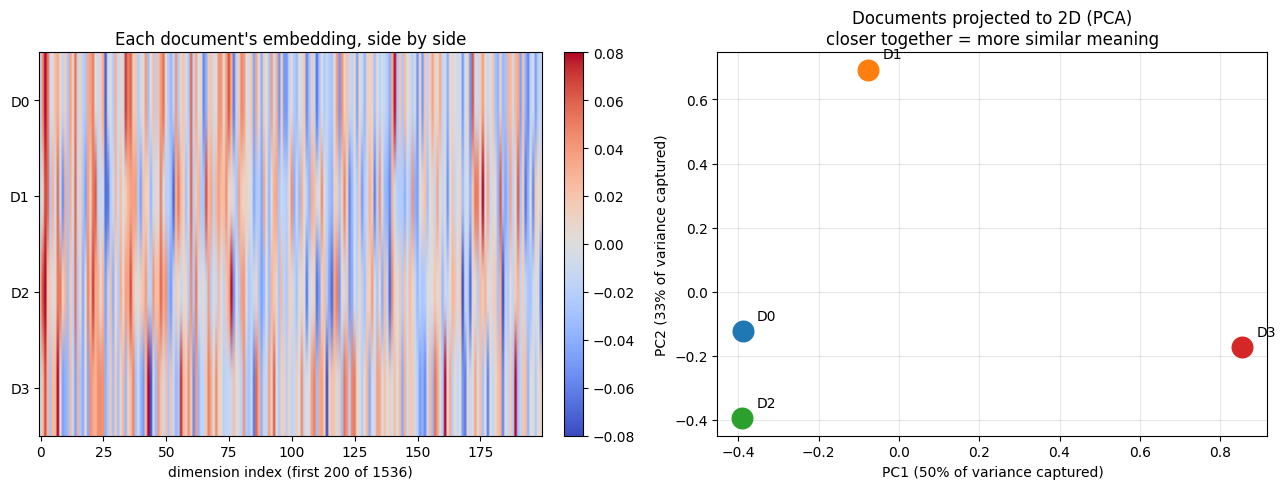

In [59]:
# Only run this visualization if a key is configured.
if HAS_KEY:

    # PCA (Principal Component Analysis) finds the 2 directions of greatest variation
    # in the data, so we can plot 1536-dimensional vectors as ordinary 2D points.
    from sklearn.decomposition import PCA

    # Build two side-by-side plots.
    figure, (heatmap_axis, scatter_axis) = plt.subplots(1, 2, figsize=(13, 5))

    # --- Left plot: heatmap, one row per document ---
    # Only show the first 200 dimensions - full width would be unreadably thin.
    n_dims_to_show = 200

    # Draw the heatmap: rows = documents, columns = embedding dimensions.
    heatmap_image = heatmap_axis.imshow(
        document_embeddings[:, :n_dims_to_show],
        aspect="auto", cmap="coolwarm", vmin=-0.08, vmax=0.08,
    )
    
    heatmap_axis.set_yticks(range(len(documents)))
    heatmap_axis.set_yticklabels([f"D{i}" for i in range(len(documents))])
    heatmap_axis.set_xlabel(f"dimension index (first {n_dims_to_show} of {document_embeddings.shape[1]})")
    heatmap_axis.set_title("Each document's embedding, side by side")
    plt.colorbar(heatmap_image, ax=heatmap_axis, fraction=0.046, pad=0.04)

    # --- Right plot: PCA projection to 2D ---
    # Fit PCA on the document embeddings and project them down to 2 dimensions.
    pca_model = PCA(n_components=2)
    doc_coordinates_2d = pca_model.fit_transform(document_embeddings)

    # Plot each document as a labelled point.
    for i, (x, y) in enumerate(doc_coordinates_2d):

        # Draw the point.
        scatter_axis.scatter(x, y, s=220, zorder=3)

        # Label it with its document index, offset slightly so text doesn't sit on the dot.
        scatter_axis.annotate(f"D{i}", (x, y), textcoords="offset points",
                              xytext=(10, 8), fontsize=10)

    scatter_axis.set_title("Documents projected to 2D (PCA)\ncloser together = more similar meaning")
    scatter_axis.set_xlabel(f"PC1 ({pca_model.explained_variance_ratio_[0]:.0%} of variance captured)")
    scatter_axis.set_ylabel(f"PC2 ({pca_model.explained_variance_ratio_[1]:.0%} of variance captured)")
    scatter_axis.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

Look at where D3 ("headquarters are located in Munich") lands versus D0/D1/D2 (all
leave/benefits related). **We never told the embedding model these documents were about
different topics** — it inferred that from meaning alone, and PCA just lets us see the
separation it created.

This is the entire mechanism retrieval relies on: semantically related text ends up
*geometrically* close in embedding space.

### Step 3 — create the query embedding

Note this is a **separate function** even though it calls the same model. In more advanced
setups (asymmetric retrieval, Chapter 10) queries and documents are genuinely encoded
differently, so keeping them separate now pays off later.

In [40]:
# Define a function that creates an embedding for the user's query.
def create_query_embedding(query):

    # Convert the single query string into one embedding vector.
    query_embedding = embed_text(query)

    # Return the query embedding.
    return query_embedding


# Define the user's question.
query = "How many annual leaves do employees receive?"

# Only call the API if a key is configured.
if HAS_KEY:

    # Generate the query embedding.
    query_embedding = create_query_embedding(query)

    # Confirm it is a 1-D vector of the same dimension as the document vectors.
    print("Query vector shape:", query_embedding.shape)

Query vector shape: (1536,)


### Now project the query into that same space

A query embedding is not special — it is produced by the exact same model, and it lives
in the exact same 1536-dimensional space as the documents. Retrieval is nothing more than
asking "which document point is nearest to the query point?"

We reuse the PCA model **already fitted on the documents** (never re-fit it on the
query — that would move the axes and make the comparison meaningless) and project the
query into it.

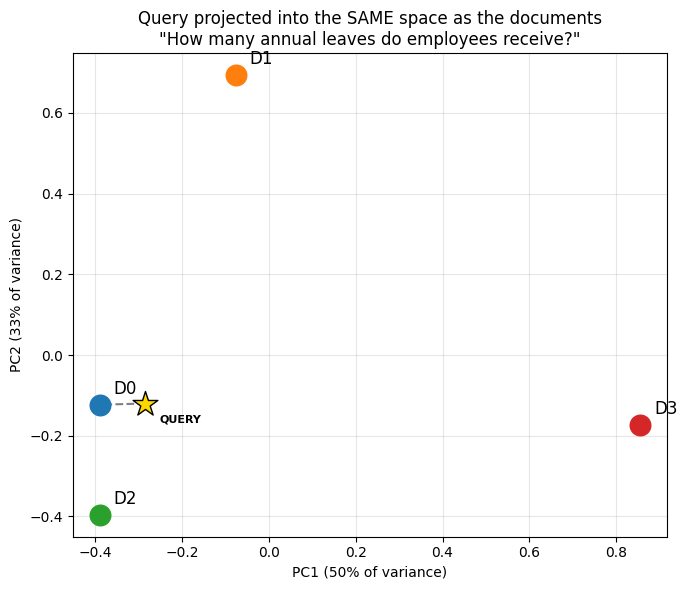

Nearest document to the query: D0 — Employees receive 24 annual leaves every year.


In [60]:
# Only run this visualization if a key is configured.
if HAS_KEY:

    # Re-fit PCA on the documents (kept separate from the cell above so this cell
    # can be re-run on its own) and project the query into that SAME fitted space.
    pca_model = PCA(n_components=2)
    doc_coordinates_2d = pca_model.fit_transform(document_embeddings)

    # .transform (not .fit_transform!) projects the query using the document axes.
    query_coordinate_2d = pca_model.transform(query_embedding.reshape(1, -1))[0]

    # Find which document is geometrically nearest to the query in this 2D view.
    distances_to_query = [
        np.linalg.norm(query_coordinate_2d - doc_point)
        for doc_point in doc_coordinates_2d
    ]
    nearest_document_index = int(np.argmin(distances_to_query))

    # Build the plot.
    figure, axis = plt.subplots(figsize=(7, 6))

    # Plot each document.
    for i, (x, y) in enumerate(doc_coordinates_2d):
        axis.scatter(x, y, s=220, zorder=3)
        axis.annotate(f"D{i}", (x, y), textcoords="offset points", xytext=(10, 8), fontsize=12)

    # Plot the query as a distinct gold star so it stands out from documents.
    axis.scatter(*query_coordinate_2d, s=350, color="gold", edgecolor="black",
                marker="*", zorder=4)
    axis.annotate("QUERY", query_coordinate_2d, textcoords="offset points",
                 xytext=(10, -14), fontsize=8, fontweight="bold")

    # Draw a dashed line from the query to its nearest document.
    nearest_point = doc_coordinates_2d[nearest_document_index]
    axis.plot([query_coordinate_2d[0], nearest_point[0]],
             [query_coordinate_2d[1], nearest_point[1]],
             linestyle="--", color="gray", zorder=2)

    axis.set_title(f'Query projected into the SAME space as the documents\n"{query}"')
    axis.set_xlabel(f"PC1 ({pca_model.explained_variance_ratio_[0]:.0%} of variance)")
    axis.set_ylabel(f"PC2 ({pca_model.explained_variance_ratio_[1]:.0%} of variance)")
    axis.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Confirm in text what the picture shows.
    print(f"Nearest document to the query: D{nearest_document_index} — {documents[nearest_document_index]}")

The gold star should sit right next to the document that actually answers the question.
The dashed line is, visually, the entire retrieval algorithm: **find the nearest point**.
Everything from here (`calculate_document_scores`, `retrieve_top_k`) is that same idea,
done properly in the full 1536 dimensions instead of a lossy 2D projection.

### Step 4 - cosine similarity, implemented by hand

Rather than hiding this behind a library call, let's implement the mathematics directly:

$$\cos(A, B) = \frac{A \cdot B}{\lVert A \rVert \lVert B \rVert}$$

You should write this from memory at least once. After that, use the library version.

In [42]:
# Define a function for cosine similarity between two vectors.
def cosine_similarity(vector_a, vector_b):

    # Calculate the dot product: sum of element-wise products of the two vectors.
    dot_product = np.dot(vector_a, vector_b)

    # Calculate the magnitude (L2 norm / length) of the first vector.
    magnitude_a = np.linalg.norm(vector_a)

    # Calculate the magnitude of the second vector.
    magnitude_b = np.linalg.norm(vector_b)

    # Multiply both magnitudes to form the denominator.
    denominator = magnitude_a * magnitude_b

    # Guard against division by zero for an all-zeros vector.
    if denominator == 0:
        return 0.0

    # Divide the dot product by the product of magnitudes.
    similarity = dot_product / denominator

    # Return the cosine similarity score, in the range [-1, 1].
    return similarity

#### Sanity-check the maths before trusting it on real embeddings

Small hand-checkable vectors first. This habit — verify on toy inputs, then scale —
will save you hours later.

In [43]:
# Two identical vectors point the exact same way, so similarity must be 1.0.
print("identical  :", cosine_similarity(np.array([1.0, 2.0, 3.0]),
                                        np.array([1.0, 2.0, 3.0])))

# One vector scaled by 10 has the same DIRECTION, so similarity is still 1.0.
# This is exactly the length-invariance we wanted.
print("scaled x10 :", cosine_similarity(np.array([1.0, 2.0, 3.0]),
                                        np.array([10.0, 20.0, 30.0])))

# Perpendicular (orthogonal) vectors share no direction at all, so similarity is 0.0.
print("orthogonal :", cosine_similarity(np.array([1.0, 0.0]),
                                        np.array([0.0, 1.0])))

# Exactly opposite vectors give -1.0, the minimum possible cosine similarity.
print("opposite   :", cosine_similarity(np.array([1.0, 0.0]),
                                        np.array([-1.0, 0.0])))

identical  : 1.0
scaled x10 : 1.0
orthogonal : 0.0
opposite   : -1.0


### Step 5 - score every document against the query

In [44]:
# Define a function that calculates similarity against every document.
def calculate_document_scores(query_embedding, document_embeddings):

    # Create an empty list to hold one similarity score per document.
    similarity_scores = []

    # Iterate over every document embedding in the index.
    for document_embedding in document_embeddings:

        # Calculate similarity between the query and the current document.
        score = cosine_similarity(query_embedding, document_embedding)

        # Add this document's score to the list.
        similarity_scores.append(score)

    # Return all similarity scores, in the same order as the documents.
    return similarity_scores


# Only run if a key is configured.
if HAS_KEY:

    # Calculate similarity between the query and every document.
    similarity_scores = calculate_document_scores(query_embedding, document_embeddings)

    # Print each document with its score so we can see the ranking emerge.
    print(f"Query: {query}\n")
    
    for index, score in enumerate(similarity_scores):
        print(f"  {score:.4f}  D{index}: {documents[index]}")

Query: How many annual leaves do employees receive?

  0.7435  D0: Employees receive 24 annual leaves every year.
  0.4048  D1: Employees receive medical insurance benefits.
  0.6186  D2: Employees can carry forward up to 10 unused leaves.
  0.1352  D3: The company headquarters are located in Munich.


### Visualize the similarity scores

The printed numbers above already tell the story. A sorted bar chart makes the *margin*
between scores visible at a glance — which matters a lot once you're deciding where to
draw the Top-K cutoff line.

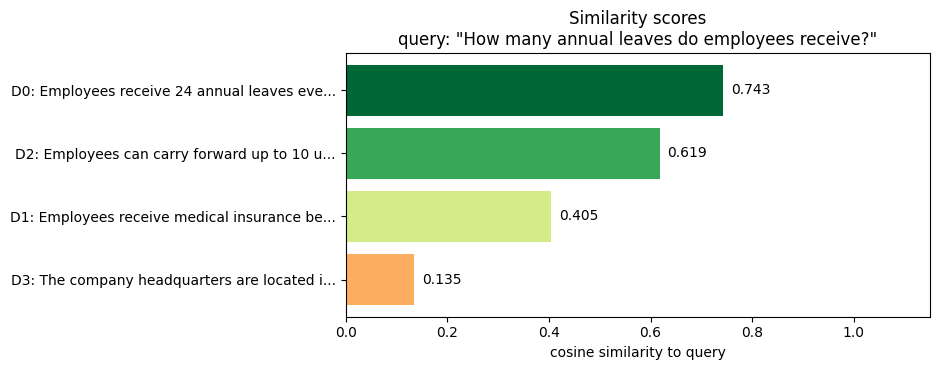

In [62]:
# Only run this visualization if a key is configured.
if HAS_KEY:

    # Sort document indexes by score, ascending, so barh (which draws bottom-up)
    # shows the highest score at the top of the chart.
    ranked_indexes = np.argsort(similarity_scores)

    # Build short labels combining the document index and a snippet of its text.
    bar_labels = [f"D{i}: {documents[i][:38]}..." for i in ranked_indexes]

    # Colour bars green (high similarity) fading to orange (low similarity).
    normalized_scores = [
        (similarity_scores[i] - min(similarity_scores))
        / (max(similarity_scores) - min(similarity_scores) + 1e-9)
        for i in ranked_indexes
    ]
    bar_colors = plt.cm.RdYlGn([0.3 + 0.7 * s for s in normalized_scores])

    # Draw the horizontal bar chart.
    figure, axis = plt.subplots(figsize=(9.5, 3.8))
    axis.barh(range(len(ranked_indexes)),
             [similarity_scores[i] for i in ranked_indexes],
             color=bar_colors)

    axis.set_yticks(range(len(ranked_indexes)))
    axis.set_yticklabels(bar_labels)
    axis.set_xlabel("cosine similarity to query")
    axis.set_xlim(0, 1.15)
    axis.set_title(f'Similarity scores\nquery: "{query}"')

    # Print the exact score next to each bar.
    for position, doc_index in enumerate(ranked_indexes):
        axis.text(similarity_scores[doc_index] + 0.015, position,
                 f"{similarity_scores[doc_index]:.3f}", va="center", fontsize=10)

    plt.tight_layout()
    plt.show()

**Read the numbers, not just the ranking.** Notice that the "leave" documents score clearly
higher than the Munich headquarters document — the embedding model has never been told
what "leave" means, it has *learned* that these sentences occupy nearby regions of a
1536-dimensional space.

Also notice the scores are all fairly high in absolute terms (often 0.3–0.8 for related
text). Cosine similarity is only meaningful **relative to other scores in the same
query**, not as an absolute "confidence". This bites people who set a fixed threshold like
`score > 0.8` and wonder why it works for one query and not another. (Chapter 15 covers
threshold-based retrieval properly.)

### Step 6 — retrieve the top-K

In [46]:
# Define a function that retrieves the k highest-scoring documents.
def retrieve_top_k(documents, similarity_scores, k):

    # argsort returns indexes that would sort ascending; [::-1] reverses to descending.
    ranked_indexes = np.argsort(similarity_scores)[::-1]

    # Keep only the first k ranked indexes.
    top_indexes = ranked_indexes[:k]

    # Create an empty list to hold the retrieved document texts.
    retrieved_documents = []

    # Iterate over each selected document index in rank order.
    for index in top_indexes:

        # Add the matching document text to the result list.
        retrieved_documents.append(documents[index])

    # Return the most relevant documents, best first.
    return retrieved_documents


# Only run if a key is configured.
if HAS_KEY:

    # Retrieve the two most relevant documents.
    retrieved_documents = retrieve_top_k(documents, similarity_scores, k=2)

    # Display what the retriever selected.
    print("Retrieved:")

    # Iterate on the retrived documents
    for document in retrieved_documents:print("  -", document)

Retrieved:
  - Employees receive 24 annual leaves every year.
  - Employees can carry forward up to 10 unused leaves.


### See exactly what Top K throws away

This is the single most important picture in the retrieval half of this chapter. Every
document above the cutoff line reaches the LLM. Every document below it **does not exist**
as far as generation is concerned — no matter how relevant it might have been.

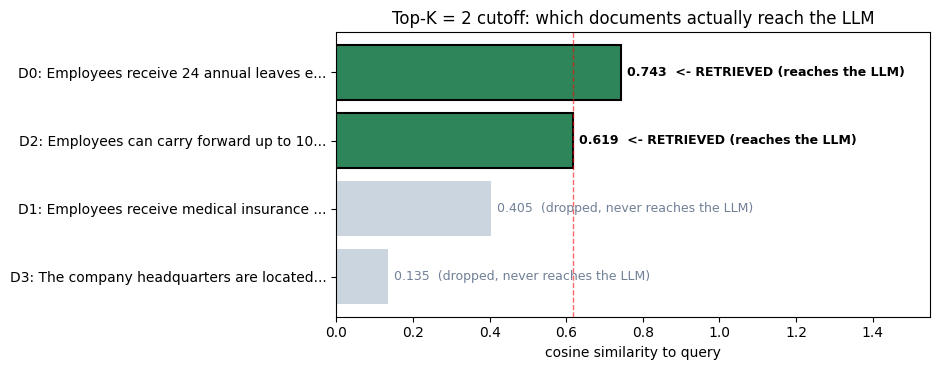

In [47]:
# Only run this visualization if a key is configured.
if HAS_KEY:

    # Which document indexes actually got retrieved at this k.
    ranked_by_score_desc = np.argsort(similarity_scores)[::-1]
    retrieved_indexes = set(ranked_by_score_desc[:2])   # matches k=2 used above

    # Sort ascending for the bottom-up barh layout, same as the previous chart.
    ranked_indexes = np.argsort(similarity_scores)
    bar_labels = [f"D{i}: {documents[i][:36]}..." for i in ranked_indexes]

    figure, axis = plt.subplots(figsize=(9.5, 3.8))

    # Draw one bar per document, colouring retrieved vs dropped differently.
    for position, doc_index in enumerate(ranked_indexes):

        # Green with a black outline for anything that made the cut.
        was_retrieved = doc_index in retrieved_indexes
        bar_color = "#2f855a" if was_retrieved else "#cbd5e0"

        axis.barh(position, similarity_scores[doc_index], color=bar_color,
                 edgecolor="black" if was_retrieved else "none", linewidth=1.5)

        # Label each bar with its score and whether it survives to the LLM.
        status_text = "  <- RETRIEVED (reaches the LLM)" if was_retrieved \
            else "  (dropped, never reaches the LLM)"
        axis.text(similarity_scores[doc_index] + 0.015, position,
                 f"{similarity_scores[doc_index]:.3f}{status_text}",
                 va="center", fontsize=9,
                 fontweight="bold" if was_retrieved else "normal",
                 color="black" if was_retrieved else "#718096")

    axis.set_yticks(range(len(ranked_indexes)))
    axis.set_yticklabels(bar_labels)
    axis.set_xlabel("cosine similarity to query")
    axis.set_xlim(0, 1.55)

    # Draw the actual cutoff line at the score of the last document that made it in.
    cutoff_score = similarity_scores[ranked_by_score_desc[1]]   # k=2, so index [k-1]
    axis.axvline(cutoff_score, color="red", linestyle="--", linewidth=1, alpha=0.6)

    axis.set_title("Top-K = 2 cutoff: which documents actually reach the LLM")

    plt.tight_layout()
    plt.show()

Everything left of the red dashed line simply doesn't exist for the LLM this turn. If the
answer had lived in one of the grey bars, no prompt engineering, no clever system message,
and no amount of LLM capability could have produced the right answer — the information
was never in the context window to begin with. This is the retrieval bottleneck from
10.2, made visible.

### Step 7 - build the context

Joining retrieved chunks into one string is the simplest possible "context construction".

It looks trivial. It is not — Chapter 17 is entirely about this step: deduplication,
ordering (the *lost-in-the-middle* problem), token budgets, and compression. For now,
newline-join.

In [48]:
# Define a function that joins retrieved documents into one context block.
def build_context(retrieved_documents):

    # Join all retrieved documents using newline characters.
    context = "\n".join(retrieved_documents)

    # Return the constructed context string.
    return context


# Only run if a key is configured.
if HAS_KEY:

    # Combine the retrieved documents into a single context.
    context = build_context(retrieved_documents)

    # Show the context exactly as the LLM will see it.
    print(context)

Employees receive 24 annual leaves every year.
Employees can carry forward up to 10 unused leaves.


### Step 8  build the RAG prompt

Three things every RAG prompt needs, and **all three matter**:

1. **A grounding instruction** — "answer using only the provided context"
2. **An escape hatch** — what to say when the context does not contain the answer
3. **Clear delimiters** — so the model can tell context from question

Without #2 the model will happily fall back on its parametric knowledge and invent an
answer, which is exactly the failure mode RAG exists to prevent.

In [49]:
# Define a function that creates the final RAG prompt.
def build_rag_prompt(context, query):

    # The instruction block: grounding rule + escape hatch when evidence is missing.
    instruction = (
        "Answer the question using only the provided context.\n"
        "If the answer cannot be determined from the context,\n"
        "say that the information is not available."
    )

    # Assemble the final prompt: instruction, then context, then question.
    prompt = (
        f"{instruction}\n\n"
        f"Context:\n{context}\n\n"
        f"Question:\n{query}\n\n"
        f"Answer:"
    )

    # Return the completed prompt.
    return prompt


# Only run if a key is configured.
if HAS_KEY:

    # Construct the final prompt for the language model.
    prompt = build_rag_prompt(context, query)

    # Print the exact string that will be sent to the API.
    print(prompt)

Answer the question using only the provided context.
If the answer cannot be determined from the context,
say that the information is not available.

Context:
Employees receive 24 annual leaves every year.
Employees can carry forward up to 10 unused leaves.

Question:
How many annual leaves do employees receive?

Answer:


### Step 9 - generate the answer

In [50]:
# Only run if a key is configured.
if HAS_KEY:

    # Send the RAG prompt to the LLM and get back the generated answer.
    answer = chat(
        prompt,
        system="You are a precise assistant that answers strictly from the given context.",
    )

    # Display the grounded answer.
    print("ANSWER:", answer)

ANSWER: Employees receive 24 annual leaves every year.


### Step 10 - wire it all together

Now the full pipeline as one function, so we can ask arbitrary questions.

In [51]:
# Define the complete naive RAG pipeline end to end.
def naive_rag(query, documents, document_embeddings, k=2, verbose=True):

    # --- RETRIEVAL ---
    # Embed the incoming user query.
    query_embedding = create_query_embedding(query)

    # Score every document in the index against the query.
    similarity_scores = calculate_document_scores(query_embedding, document_embeddings)

    # Keep only the top-k most similar documents.
    retrieved = retrieve_top_k(documents, similarity_scores, k)

    # --- AUGMENTATION ---
    # Join the retrieved documents into a single context block.
    context = build_context(retrieved)

    # Insert the context and question into the grounded prompt template.
    prompt = build_rag_prompt(context, query)

    # --- GENERATION ---
    # Ask the LLM to answer using only that context.
    answer = chat(prompt, system="Answer strictly from the given context.")

    # Optionally show what was retrieved - essential for debugging.
    if verbose:
        print(f"Q: {query}")
        print("  retrieved:")
        for document in retrieved:
            print("    -", document)
        print(f"  A: {answer}\n")

    # Return both the answer and the evidence that produced it.
    return answer, retrieved

In [52]:
# Only run if a key is configured.
if HAS_KEY:

    # A question the knowledge base CAN answer.
    naive_rag("How many annual leaves do employees receive?",
              documents, document_embeddings)

    # A different question the knowledge base CAN answer.
    naive_rag("Where is the company headquarters?",
              documents, document_embeddings)

    # A question the knowledge base CANNOT answer - watch the escape hatch fire.
    naive_rag("What is the company's parental leave policy?",
              documents, document_embeddings)

Q: How many annual leaves do employees receive?
  retrieved:
    - Employees receive 24 annual leaves every year.
    - Employees can carry forward up to 10 unused leaves.
  A: Employees receive 24 annual leaves every year.

Q: Where is the company headquarters?
  retrieved:
    - The company headquarters are located in Munich.
    - Employees receive 24 annual leaves every year.
  A: The company headquarters are located in Munich.

Q: What is the company's parental leave policy?
  retrieved:
    - Employees receive 24 annual leaves every year.
    - Employees can carry forward up to 10 unused leaves.
  A: The information is not available.



> **Run that third question and read the answer carefully.** The model should say the
> information is not available. That refusal is a *feature*, and it only works because we
> put the escape hatch in the prompt. Try deleting that line from `build_rag_prompt` and
> re-running — you will very likely get a confident, invented parental-leave policy. That
> is the single most instructive experiment in this chapter.

### What the LLM did *not* do

This is the distinction people most often get wrong:

```
The LLM did NOT:
    search the vector database
    create embeddings
    calculate cosine similarity
    select documents
```

**Your application did all of that.** The LLM only ever saw a string that looked like:

```
<context>
...
</context>

<question>
...
</question>
```

The LLM is the last box in the pipeline, not the pipeline.


# 8. The hallucination problem

## 8.1 Why LLMs hallucinate

An LLM optimizes roughly for:

$$P(\text{next token} \mid \text{previous tokens})$$

It has no built-in mechanism equivalent to:

```python
if fact_not_known:
    refuse()
```

So when asked *"What is ABC Company's refund window?"* and it doesn't know, the most
*probable* continuation is still a fluent, specific-sounding answer:
*"ABC Company provides a 30-day refund policy."*

That is a hallucination — not a bug in the model, but the direct consequence of what it
was trained to optimize.

## 8.2 Does RAG eliminate hallucination?

**No.** This is a classic interview trap.

RAG **reduces** hallucination. It does **not eliminate** it. Hallucination still happens when:

```
Wrong document retrieved
Correct document only partially retrieved
Document is outdated
Contradictory documents retrieved
LLM ignores the context
Context is too long
Important information is lost in the middle
Question is ambiguous
Retriever returns low-quality chunks
```

Therefore:

$$\text{RAG} \neq \text{guaranteed truth}$$

The correct formulation:

> **RAG increases the probability that generated answers are grounded in externally
> supplied evidence.**

## 8.3 Similarity ≠ answerability

A subtle and important failure. Query: *"What is the maximum maternity leave?"*

| Chunk | Text | Similarity |
|---|---|---|
| A | "Maternity leave is available to eligible employees." | **0.94** |
| B | "Eligible employees may receive up to 26 weeks of maternity leave." | 0.88 |

Chunk A scores *higher* but **does not contain the answer**. Chunk B does.

$$\text{Similarity} \neq \text{Answerability}$$

This single observation is the entire motivation for **reranking** (Chapter 16): a
cross-encoder reads the query and chunk *together* and asks "does this actually answer the
question?", which a bi-encoder similarity score cannot.

Let's watch it happen.

In [35]:
# Two chunks: one is topically similar, the other actually contains the answer.
maternity_chunks = [
    "Maternity leave is available to eligible employees.",
    "Eligible employees may receive up to 26 weeks of maternity leave.",
]

# The question specifically asks for a MAXIMUM - a number.
maternity_query = "What is the maximum maternity leave?"

# Only run if a key is configured.
if HAS_KEY:

    # Embed the two candidate chunks.
    chunk_vectors = embed_texts(maternity_chunks)

    # Embed the query.
    query_vector = embed_text(maternity_query)

    # Score each chunk against the query.
    for chunk, vector in zip(maternity_chunks, chunk_vectors):
        score = cosine_similarity(query_vector, vector)
        print(f"{score:.4f}  {chunk}")

0.6491  Maternity leave is available to eligible employees.
0.7141  Eligible employees may receive up to 26 weeks of maternity leave.


Whichever way the scores land for you, the lesson stands: **the top-scoring chunk is not
guaranteed to be the answer-bearing chunk.** Pure vector similarity is a *proxy* for
relevance, and proxies leak.

## 8.4 A chunking failure that looks like a retrieval failure

Source document says:

```
Employees with at least five years of service
receive 30 annual leave days.
```

But chunking splits it badly:

```
Chunk 1: Employees with at least five years of
Chunk 2: service receive 30 annual leave days.
```

User asks: *"Who receives 30 annual leave days?"*

The retriever returns Chunk 2 — which contains "30 annual leave days" but has **lost the
condition** "five years of service". The LLM now confidently tells every employee they get
30 days.

This is why Chapter 3 (chunking) is far more important than it first appears.


# 9. RAG vs the alternatives

## 9.1 Plain LLM vs RAG

| Property | Plain LLM | RAG |
|---|---|---|
| Knowledge | Model parameters | Parameters + external data |
| Fresh data | Limited | Yes |
| Private data | Usually unavailable | Yes |
| Citations | Difficult | Easier |
| Updating knowledge | Retrain / fine-tune | Update index |
| Retrieval errors | None (no retrieval) | Possible |
| Infrastructure | Simpler | More complex |
| Latency | Lower | Higher |
| Explainability | Lower | Better, with evidence |

## 9.2 RAG vs fine-tuning

**The single most common GenAI interview question.**

**Fine-tuning** changes $\theta$ — the model parameters:

```
Training examples
       │
       ▼
  Fine-Tuning
       │
       ▼
Updated weights
```

Use it primarily to change: **Behavior · Style · Format · Domain patterns · Task performance**

**RAG** keeps $\theta$ fixed and supplies *Context* at inference time:

```
External Knowledge
       │
       ▼
   Retriever
       │
       ▼
    Context
       │
       ▼
      LLM
```

Use it primarily to supply: **Knowledge · Fresh information · Private information · Evidence**

### The rule that wins interviews

```
Need to teach the model HOW?      →  Fine-tuning
Need to provide the model WHAT?   →  RAG
```

| Requirement | Answer |
|---|---|
| "Always output insurance claims in this JSON schema." | Fine-tuning (or prompting) |
| "Answer from today's insurance-policy documents." | RAG |

### They are not mutually exclusive

```
Domain Data
    │
    ▼
Fine-tuned Model
    │
    │
User Query ──► Retriever
    │
    ▼
 Context
    │
    ▼
Fine-tuned LLM
    │
    ▼
 Answer
```

*Example:* fine-tune the model for legal writing style; use RAG to supply current legislation.

## 9.3 RAG vs long-context LLMs

Modern models accept enormous context windows. So why not just send everything?

**Because you can't afford to.** Suppose:

```
100,000 documents  ×  2,000 tokens/document  =  200,000,000 tokens
```

Sending 200M tokens on every request is impossible — and even if the model accepted it,
it would be **expensive, slow, noisy and hard to reason over**.

RAG instead does:

```
200,000,000 tokens
       ↓ retrieval
5 chunks × 500 tokens
       ↓
     2,500 tokens
```

### RAG as an information bottleneck

```
Huge Knowledge Base
  100 million tokens
        │
        ▼
    Retriever
        │
        ▼
   10,000 tokens
        │
        ▼
    Reranker
        │
        ▼
    3,000 tokens
        │
        ▼
       LLM
```

$$\text{Huge Corpus} \rightarrow \text{Small Relevant Context}$$

### When to use which

| Situation | Better starting point |
|---|---|
| 10-page PDF | Long context |
| 50-page report | Often long context |
| 10,000 documents | RAG |
| Millions of documents | RAG |
| Need access control | RAG |
| Frequently updated documents | RAG |
| Need exact source retrieval | RAG |
| Heavy cross-document reasoning | Often RAG + long context |

They are **complementary, not competitors**:

```
Large corpus
     │
     ▼
 Retrieval
     │
     ▼
Relevant subset
     │
     ▼
Long-context LLM
```

### The lost-in-the-middle problem

Even when a model *accepts* huge context, it does not necessarily *use* all of it equally:

```
Context

Important fact A
     │
     │
 100 pages
     │
IMPORTANT FACT X  ← the one you need
     │
 100 pages
     │
Important fact B
```

Models pay disproportionate attention to the **beginning and end** of a long context.
Retrieval remains valuable precisely because it puts the most relevant information into a
small, well-positioned working context. (Chapter 17 covers how to order context to exploit this.)

## 9.4 When to use RAG

**Good cases:**

1. **Private enterprise knowledge** — HR documents, SOPs, internal manuals, policies, product docs
2. **Frequently changing information** — policies, pricing, regulations, news, catalogs, inventory
3. **Very large knowledge base** — millions of documents
4. **Citation requirement** — answer + source
5. **Domain-specific knowledge** — legal, healthcare, finance, engineering, regulatory

## 9.5 When NOT to use RAG

RAG is not automatically the answer to every LLM problem.

| Case | Example | Why not |
|---|---|---|
| **Creative writing** | "Write a poem about rain." | No retrieval needed |
| **Transformation task** | "Summarize this paragraph." / "Translate this email." | The user already supplied the information |
| **Simple reasoning** | "If Alice has 5 apples and gives 2 away…" | No external knowledge required |
| **Small doc fits in context** | A 20-page upload, questions only about it | Direct long-context prompting is simpler |
| **Knowledge must become behavior** | "Always respond in this format" | Prompting or fine-tuning is more appropriate |

## 9.6 RAG's disadvantages

RAG creates an entirely new engineering stack.

```
Plain LLM:              RAG:

User                    User
 │                       │
 ▼                       ▼
LLM                  Query processing
 │                       │
 ▼                       ▼
Answer               Embedding API
                         │
                         ▼
                     Vector DB
                         │
                         ▼
                      Retriever
                         │
                         ▼
                      Reranker
                         │
                         ▼
                   Context builder
                         │
                         ▼
                        LLM
                         │
                         ▼
                     Guardrails
                         │
                         ▼
                      Answer
```

More components mean **more latency, more cost, more failure points, more monitoring,
more infrastructure.** Do not add RAG reflexively.


# 10. Failure modes & the debugging ladder

## 10.1 The failure taxonomy

Memorize the three buckets:

```
                    RAG FAILURE
                         │
      ┌──────────────────┼──────────────────┐
      │                  │                  │
      ▼                  ▼                  ▼
  INGESTION          RETRIEVAL          GENERATION
      │                  │                  │
  Bad parsing       Wrong chunks       Hallucination
  Bad chunking      Bad ranking        Misinterpretation
  Missing data      Bad query          Citation errors
```

## 10.2 The retrieval bottleneck

Suppose the correct answer lives in Chunk 91, but retrieval returns:

```
Top 5:  Chunk 12, Chunk 42, Chunk 56, Chunk 72, Chunk 83
```

Chunk 91 never reaches the LLM. **The LLM cannot use information it was never given.**

$$\text{Correct answer exists} \;\neq\; \text{Correct answer retrieved}$$

This is exactly why **Recall@K** becomes the metric that matters (Chapter 35).

Let's demonstrate the bottleneck directly.

In [36]:
# Only run if a key is configured.
if HAS_KEY:

    # A query whose answer lives in D2 ("carry forward up to 10 unused leaves").
    carry_query = "Can I carry unused leaves into next year?"

    # Embed the query once and reuse it for both k values.
    carry_vector = create_query_embedding(carry_query)

    # Score every document against the query.
    carry_scores = calculate_document_scores(carry_vector, document_embeddings)

    # Show the full ranking so we can see where the answer-bearing chunk sits.
    print("Full ranking:")
    for rank, index in enumerate(np.argsort(carry_scores)[::-1], start=1):
        print(f"  rank {rank}: {carry_scores[index]:.4f}  {documents[index]}")

    # Now retrieve with a deliberately tiny k to show what gets cut off.
    print("\nWith k=1 the LLM only sees:")
    for document in retrieve_top_k(documents, carry_scores, k=1):
        print("  -", document)

Full ranking:
  rank 1: 0.5569  Employees can carry forward up to 10 unused leaves.
  rank 2: 0.3613  Employees receive 24 annual leaves every year.
  rank 3: 0.0994  Employees receive medical insurance benefits.
  rank 4: 0.0101  The company headquarters are located in Munich.

With k=1 the LLM only sees:
  - Employees can carry forward up to 10 unused leaves.


Try changing `k=1` to `k=2` above. If the answer-bearing document sat at rank 2, then
`k=1` guarantees a wrong answer **no matter how good your LLM is**. That is the retrieval
bottleneck in one experiment.

## 10.3 The debugging ladder

When a user reports a wrong answer, walk down this ladder in order. Do **not** start by
blaming the prompt.

```
Wrong answer
    │
    ▼
Does the source document contain the correct answer?
    ├── NO  → source-data issue (you don't have the knowledge)
    └── YES
         │
         ▼
    Was it parsed correctly?
         ├── NO  → ingestion issue      (Chapter 2)
         └── YES
              │
              ▼
         Was it chunked properly?
              ├── NO  → chunking issue  (Chapter 3)
              └── YES
                   │
                   ▼
              Was the chunk retrieved?
                   ├── NO  → retrieval issue  (Chapters 8-15)
                   └── YES
                        │
                        ▼
                   Did the reranker keep it?
                        ├── NO  → ranking issue  (Chapter 16)
                        └── YES
                             │
                             ▼
                        Did the LLM answer correctly?
                             ├── NO  → generation issue  (Chapters 19-20)
                             └── YES → not actually a bug
```

**This diagram is worth memorizing** for both interviews and production on-call.

## 10.4 Why production RAG is hard

Building a demo takes minutes:

```
PDF → Chunks → Embeddings → Vector DB → LLM
```

Building a production system that works *consistently* means answering all of this:

```
How should documents be parsed?      What chunk size?       Which ANN algorithm?
How should they be chunked?          What overlap?          Metadata filters?
Which embedding model?               Top K = ?              Reranker?
Vector or BM25?                      Hybrid search?         How many chunks after reranking?

How do we prevent hallucination?     How do we evaluate retrieval?
How do we evaluate answers?          How do we handle permissions?
How do we update documents?          How do we scale to millions of chunks?
How do we monitor failures?          How do we manage latency?
How do we control costs?
```

Those questions are, essentially, the remaining 54 chapters of this course.


# 11. Interview preparation

## 11.1 The seven traps

| ❌ Wrong statement | ✅ Correction |
|---|---|
| "RAG removes hallucination." | RAG *reduces* hallucination by grounding generation in retrieved evidence. It does not eliminate it. |
| "RAG requires a vector database." | Wrong. BM25, SQL, Elasticsearch, graph DBs, search APIs and web search all work. |
| "RAG trains the LLM using documents." | Wrong. Typical RAG does **not** modify weights. Documents go into the *prompt*, and are forgotten when the request ends. |
| "Highest cosine similarity always means correct answer." | Wrong. Similarity ≠ answerability. |
| "Large context windows make RAG obsolete." | Wrong for large-scale knowledge systems. They are complementary. |
| "If retrieval is correct, the answer must be correct." | Wrong. Generation can still fail. |
| "Fine-tuning is a replacement for RAG." | Wrong. They solve different problems and combine well. |

### Two more misconceptions worth naming

**"Vector DB = RAG"** — No. A vector database is *one possible* retrieval component. You
could build RAG with BM25, Elasticsearch, SQL, a knowledge graph, Google Search, an API,
or hybrid search.

$$\text{RAG} \neq \text{Vector Database}$$

$$\text{RAG} = \text{Retrieve external information} + \text{Generate using that information}$$

**"RAG must use embeddings"** — Also false. This is still RAG:

```
Question → BM25 Search → Documents → LLM
```

And so is this:

```
Question → SQL query → Database rows → LLM
```

## 11.2 Model answers

### Q: "Explain RAG."

> RAG, or Retrieval-Augmented Generation, is an architecture where an LLM's parametric
> knowledge is augmented at inference time with information retrieved from an external
> knowledge source. Typically, documents are parsed, chunked, embedded, and indexed. At
> query time, the query is transformed into a representation and relevant documents are
> retrieved using dense, sparse, or hybrid retrieval. The highest-quality evidence is
> optionally reranked and inserted into the model's context, allowing the LLM to generate
> an answer grounded in external information. RAG is useful for private, frequently
> changing, or very large knowledge bases because information can be updated without
> retraining the LLM.

Compare that to the weak version: *"RAG means we store PDFs in a vector DB and ask GPT questions."*

### Q: "Does RAG solve hallucination?"

> It reduces hallucination but does not eliminate it. Errors can occur because the correct
> evidence may not be retrieved, retrieval may return irrelevant or conflicting
> information, or the generator may ignore or misinterpret retrieved evidence. A robust
> RAG system therefore needs retrieval evaluation, reranking, grounding instructions,
> citation validation, and generation-quality evaluation.

### Q: "Why RAG instead of fine-tuning?"

> Fine-tuning changes model behavior and parameters; RAG injects external knowledge at
> inference. For frequently changing factual knowledge, RAG is usually much easier to
> maintain — you update a document and re-index, rather than collecting data and retraining.

### Q: "Can RAG work without a vector DB?"

> Absolutely. Possible retrieval engines include BM25, SQL, Elasticsearch, graph databases,
> search APIs, vector databases and web search. The essential idea is *external retrieval*,
> not vectors themselves.

### Q: "What are the components of RAG?"

> 1. Data ingestion  2. Parsing  3. Chunking  4. Embedding/indexing  5. Query processing
> 6. Retrieval  7. Reranking  8. Context construction  9. Generation  10. Evaluation
> 11. Monitoring

### Q: "Design an internal enterprise knowledge assistant."

Do **not** open with "vector DB". Think in layers:

```
                    USERS
                      │
                      ▼
                 API Gateway
                      │
                      ▼
              Query Understanding
                      │
                      ▼
                  Retrieval
                   /      \\
                BM25      Dense
                   \\      /
                    Fusion
                      │
                      ▼
                   Reranker
                      │
                      ▼
                Context Builder
                      │
                      ▼
                     LLM
                      │
                      ▼
                Grounding Check
                      │
                      ▼
                   Response


                 OFFLINE SIDE

Documents → Connectors → Parser → Chunker → Embeddings → Vector DB
```

## 11.3 Your turn — answer these from memory

1. Why is cosine similarity preferred over Euclidean distance for text embeddings?
2. A user gets a wrong answer. Walk me through your debugging process.
3. When would you deliberately choose *not* to use RAG?
4. Your retriever has 0.95 precision but the system still gives wrong answers. What's happening?
5. Why do indexing and query pipelines have different engineering requirements?
6. Explain $P(y|x) = \sum_z P(z|x)P(y|x,z)$ and what each term means for debugging.


# 12. Chapter summary

## The key equations

**Embedding**
$$E(x) \rightarrow \mathbb{R}^d$$

**Cosine similarity**
$$\cos(q, d) = \frac{q \cdot d}{\lVert q \rVert \lVert d \rVert}$$

**Top-K retrieval**
$$D_K = \text{TopK}_{d_i}\; \text{sim}(E(Q), E(d_i))$$

**Generation** — without RAG: $P(Y|Q)$ · with RAG: $P(Y|Q, D_K)$

**Conceptual RAG probability**
$$P(y \mid x) = \sum_z P(z \mid x) P(y \mid x, z)$$

Remember what this means:

```
P(z | x)
   └── Did I retrieve the correct evidence?

P(y | x, z)
   └── Did the LLM generate correctly from it?
```

## The single most important diagram

```
             KNOWLEDGE PIPELINE

Documents → Parse → Chunk → Embed → Index → Vector / Search Database


               QUERY PIPELINE

User Query → Query Understanding → Retrieval → Relevant Evidence
          → Context Construction → LLM → Grounded Answer
```

And mentally divide every RAG bug into:

```
        RAG QUALITY
             │
      ┌──────┴──────┐
      │             │
  Retrieval     Generation
   Quality       Quality
```

## Eight things to remember

1. **RAG = retrieve external knowledge and provide it to an LLM during generation.**
2. LLM weights hold **parametric knowledge**; the external store is **non-parametric knowledge**.
3. RAG normally **does not modify LLM weights**.
4. The basic pipeline is: Documents → Chunk → Embed → Index, then Query → Retrieve → Context → LLM → Answer.
5. RAG is valuable for **private, fresh, domain-specific and large-scale** knowledge.
6. RAG **does not eliminate hallucination**.
7. RAG **does not require vector databases** — BM25, SQL, graphs and APIs all work.
8. Always separate RAG failures into **retrieval failure vs generation failure**.

---

## Exercises

1. **Break the escape hatch.** Remove the "If the answer cannot be determined…" line from
   `build_rag_prompt` and ask about parental leave. Does the model invent a policy?
2. **Find the k that breaks it.** Add 10 more documents about unrelated topics. At what
   `k` does the leave question start failing?
3. **Reproduce the chunking failure.** Split *"Employees with at least five years of service
   receive 30 annual leave days."* across two documents, then ask *"Who receives 30 days?"*
   Does the system lose the condition?
4. **Test similarity ≠ answerability.** Write three chunk pairs where the topically-similar
   chunk lacks the answer. How often does pure cosine similarity pick wrong?
5. **Implement Euclidean distance** as an alternative scorer and compare rankings. When do
   they disagree?

---

## → Next: [Chapter 2 — Documents, Data Sources & Ingestion](../02_documents_data_sources_ingestion/)

Chapter 2 goes *before* embeddings, into what most people skip:

```
PDF / DOCX / HTML / JSON / DB
            │
            ▼
       Extraction
            │
            ▼
        Parsing
            │
            ▼
        Cleaning
            │
            ▼
  Layout Understanding
            │
            ▼
     Tables / Images
            │
            ▼
        Metadata
            │
            ▼
   Ready for Chunking
```

A surprising amount of RAG failure begins **before retrieval even starts**: bad PDF
extraction, broken tables, wrong reading order, missing metadata, repeated headers and
footers, OCR noise.